# 01. PyTorch Workflow

In [1]:
# Import necessary libraries
from pathlib import Path

from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim

In [2]:
# Setup device-agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
!nvidia-smi

Wed Mar  4 11:24:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [4]:
# Create the data parameters
w = torch.tensor(data=[0.3], device=device)
b = torch.tensor(data=[0.9], device=device)

# Make X and y using linear regression feature
# X.shape should be (100, 1)
X = torch.arange(start=0, end=1, step=1e-2).unsqueeze(dim=1).to(device=device)
y = w * b + X

print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\n\ny: {y[:10]}")

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]], device='cuda:0')

y: tensor([[0.2700],
        [0.2800],
        [0.2900],
        [0.3000],
        [0.3100],
        [0.3200],
        [0.3300],
        [0.3400],
        [0.3500],
        [0.3600]], device='cuda:0')


In [5]:
# Split the data into training and testing
n = len(X)
split = int(0.8 * n)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

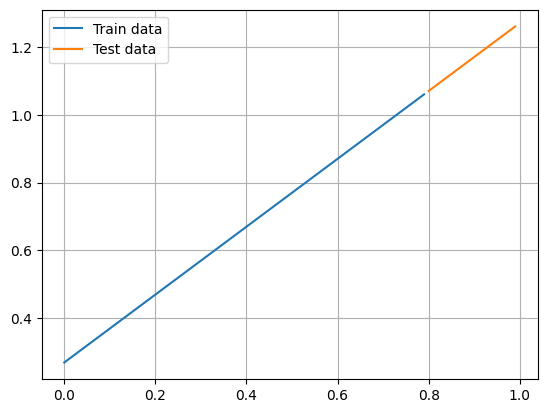

In [6]:
# Plot the training and testing data
plt.plot(X_train.cpu(), y_train.cpu(), label='Train data')
plt.plot(X_test.cpu(), y_test.cpu(), label='Test data')
plt.grid()
plt.legend()
plt.show()

## 2. Build a PyTorch model by subclassing `nn.Module`.
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`.
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1.
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [7]:
# Create PyTorch linear regression model by subclassing nn.Module
torch.manual_seed(29)
torch.cuda.manual_seed(29)


class MyModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.weights = nn.Parameter(data=torch.randn(1), requires_grad=True)
        self.bias = nn.Parameter(data=torch.randn(1), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [8]:
# Instantiate the model and put it to the target device
model = MyModel()
model.to(device)
model.state_dict()

OrderedDict([('weights', tensor([1.1474], device='cuda:0')),
             ('bias', tensor([-0.1417], device='cuda:0'))])

## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [ ]:
# Create the loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.SGD(params=model.parameters(), lr=1e-2)

In [10]:
# Training loop
torch.manual_seed(29)
torch.cuda.manual_seed(29)
train_loss_values: list[float] = []
test_loss_values: list[float] = []

# Train model for 300 epochs
epochs = 300

for epoch in tqdm(range(epochs), desc='Training process'):
  ### Training

  # Put model in train mode
  model.train()
  # 1. Forward pass
  y_pred = model(X_train)
  # 2. Calculate loss
  loss = loss_fn(y_pred, y_train)
  train_loss_values.append(loss.item())
  # 3. Zero gradients
  optimizer.zero_grad()
  # 4. Backpropagation
  loss.backward()
  # 5. Step the optimizer
  optimizer.step()

  ### Perform testing every 20 epochs
  if epoch % 20 == 0:
      # Put model in evaluation mode and setup inference context
      model.eval()
      with torch.inference_mode():
          # 1. Forward pass
          test_pred = model(X_test)
          # 2. Calculate test loss
          test_loss = loss_fn(test_pred, y_test)
          test_loss_values.append(test_loss.item())
          # Print out what's happening
          print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Training process:  43%|████▎     | 128/300 [00:00<00:00, 701.95it/s]

Epoch: 0 | Train loss: 0.353 | Test loss: 0.266
Epoch: 20 | Train loss: 0.122 | Test loss: 0.012
Epoch: 40 | Train loss: 0.049 | Test loss: 0.105
Epoch: 60 | Train loss: 0.042 | Test loss: 0.097
Epoch: 80 | Train loss: 0.035 | Test loss: 0.081
Epoch: 100 | Train loss: 0.028 | Test loss: 0.066
Epoch: 120 | Train loss: 0.021 | Test loss: 0.050
Epoch: 140 | Train loss: 0.015 | Test loss: 0.034
Epoch: 160 | Train loss: 0.008 | Test loss: 0.017
Epoch: 180 | Train loss: 0.006 | Test loss: 0.004
Epoch: 200 | Train loss: 0.006 | Test loss: 0.004


Training process: 100%|██████████| 300/300 [00:00<00:00, 887.05it/s]

Epoch: 220 | Train loss: 0.006 | Test loss: 0.004
Epoch: 240 | Train loss: 0.006 | Test loss: 0.004
Epoch: 260 | Train loss: 0.006 | Test loss: 0.004
Epoch: 280 | Train loss: 0.006 | Test loss: 0.004


## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [11]:
# Make predictions with the model
model.eval()
with torch.inference_mode():
    pred = model(X_test)

pred

tensor([[1.0788],
        [1.0889],
        [1.0990],
        [1.1090],
        [1.1191],
        [1.1292],
        [1.1393],
        [1.1493],
        [1.1594],
        [1.1695],
        [1.1796],
        [1.1896],
        [1.1997],
        [1.2098],
        [1.2199],
        [1.2299],
        [1.2400],
        [1.2501],
        [1.2602],
        [1.2702]], device='cuda:0')

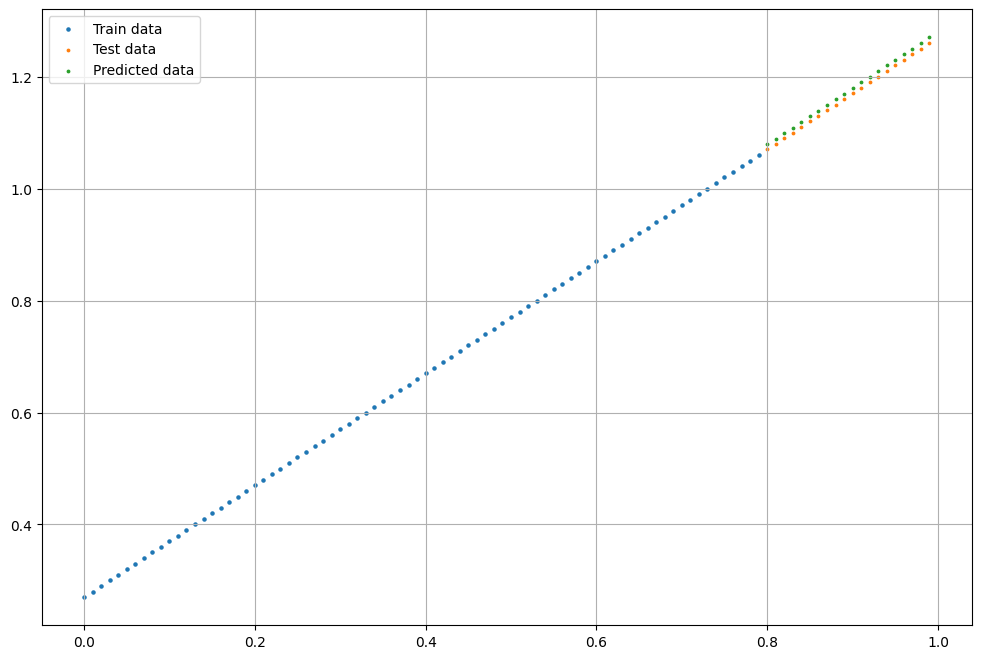

In [12]:
# Plot the predictions (these may need to be on a specific device)
plt.figure(figsize=(12, 8))
plt.scatter(x=X_train.cpu(), y=y_train.cpu(), label='Train data', s=5)
plt.scatter(x=X_test.cpu(), y=y_test.cpu(), label='Test data', s=3)
plt.scatter(x=X_test.cpu(), y=pred.cpu(), label='Predicted data', s=3)
plt.grid()
plt.legend()
plt.show();

## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [13]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path('models/')
# 2. Create model save path
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / 'simple_linear_regression.pth'
# 3. Save the model state dict
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [14]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
lin_reg_model = MyModel()
lin_reg_model.load_state_dict(state_dict=torch.load(f=MODEL_SAVE_PATH))
lin_reg_model.to(device)

MyModel()

In [15]:
# Make predictions with loaded model and compare them to the previous
lin_reg_model(X_test) == pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')